In [ ]:
# Librerías
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import chi2, t, f, norm, binom

import sympy
from sympy.abc import x
import pandas as pd

---
# Parte I: Distribuciones Muestrales
---

# Distribuciones muestrales


Cuando obtenemos una muestra aleatoria $X_1, \ldots, X_n$ de una población, construimos **estadísticos** como $\bar{X}$ o $S^2$. Las **distribuciones muestrales** describen el comportamiento probabilístico de estos estadísticos y son la base de la inferencia estadística: permiten construir intervalos de confianza y realizar pruebas de hipótesis.

## Distribución Chi-Cuadrada


### Definición y propiedades

Sea $Z_1, \ldots, Z_k$ variables aleatorias independientes $N(0,1)$. Entonces:
$$\chi^2(k) = \sum_{i=1}^k Z_i^2$$

- **Parámetros:** $k$ grados de libertad
- $\mathbb{E}[X] = k$, $\operatorname{Var}(X) = 2k$
- **PDF:** $f(x) = \dfrac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma(k/2)}, \quad x > 0$

**Cuándo se usa:** intervalos de confianza y pruebas para la varianza $\sigma^2$; prueba de bondad de ajuste; prueba de independencia en tablas de contingencia.

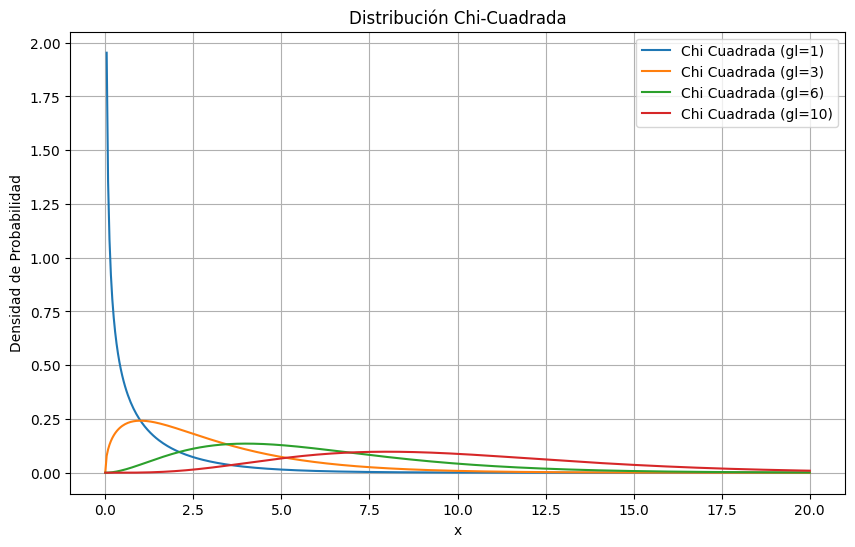

In [12]:
x_chi = np.linspace(0, 20, 500)
plt.figure(figsize=(10, 6))

# Damos los grados de libertad
gl_chi = [1,3,6,10]

for gl in gl_chi:
    plt.plot(x_chi, chi2.pdf(x_chi, gl), label=f'Chi Cuadrada (gl={gl})')
plt.title('Distribución Chi-Cuadrada')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

## t de student


### Definición y propiedades

Sea $Z \sim N(0,1)$ independiente de $W \sim \chi^2(k)$. Entonces:
$$t(k) = \frac{Z}{\sqrt{W/k}}$$

- **Parámetros:** $k$ grados de libertad
- $\mathbb{E}[X] = 0$ (para $k > 1$), $\operatorname{Var}(X) = \dfrac{k}{k-2}$ (para $k > 2$)
- Es simétrica alrededor de cero y converge a $N(0,1)$ cuando $k \to \infty$

**Cuándo se usa:** intervalos de confianza y pruebas para la media $\mu$ cuando $\sigma^2$ es **desconocida** y la muestra es pequeña.

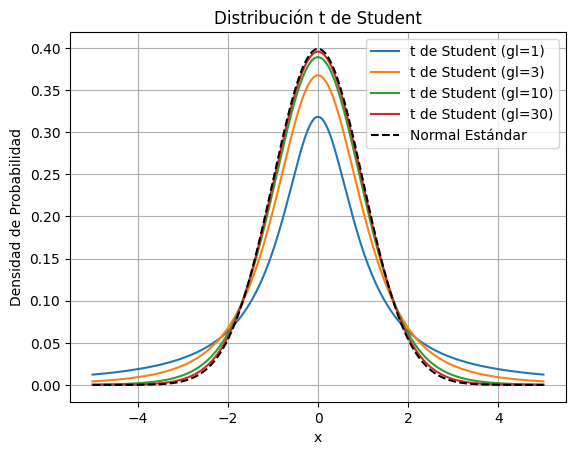

In [13]:
x = np.linspace(-5, 5, 500)

# Grados de libertad
gl_t = [1,3,10,30]

for gl in gl_t:
    plt.plot(x, t.pdf(x, gl), label=f't de Student (gl={gl})')

plt.plot(x,norm.pdf(x),'k--', label='Normal Estándar')
plt.title('Distribución t de Student')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

## F de Fisher


### Definición y propiedades

Sean $W_1 \sim \chi^2(d_1)$ y $W_2 \sim \chi^2(d_2)$ independientes. Entonces:
$$F(d_1, d_2) = \frac{W_1/d_1}{W_2/d_2}$$

- **Parámetros:** $d_1$ (grados de libertad numerador), $d_2$ (denominador)
- $\mathbb{E}[X] = \dfrac{d_2}{d_2-2}$ (para $d_2 > 2$)

**Cuándo se usa:** comparación de varianzas de dos poblaciones; análisis de varianza (ANOVA); pruebas de significancia en regresión lineal.

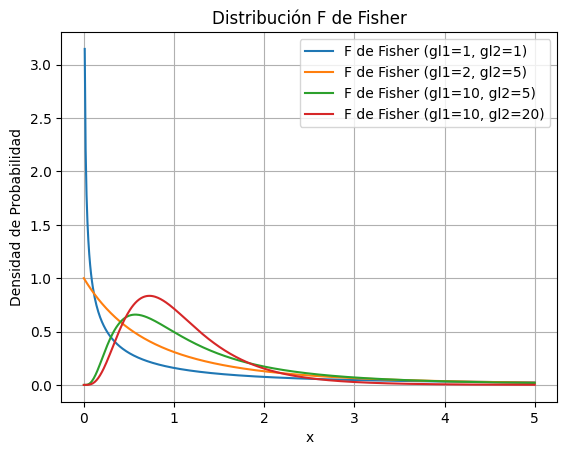

In [16]:
x = np.linspace(0, 5, 500)
# Grados de libertad
gl_f = [(1,1), (2,5), (10,5), (10,20)]
for gl1, gl2 in gl_f:
    plt.plot(x, f.pdf(x, gl1, gl2), label=f'F de Fisher (gl1={gl1}, gl2={gl2})')
plt.title('Distribución F de Fisher')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid()
plt.show()

---
# Parte II: Estimadores — EMV y Método de Momentos
---

# Estimador Máximo Verosímil


## Conceptos fundamentales

Sea $X_1, \ldots, X_n$ una muestra aleatoria de una distribución con parámetro desconocido $\theta$.

- **Estimador:** estadístico $\hat{\theta} = T(X_1,\ldots,X_n)$ que aproxima $\theta$
- **Sesgo:** $B(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta$; insesgado si $B = 0$
- **Consistencia:** $\hat{\theta} \xrightarrow{P} \theta$ cuando $n \to \infty$
- **Eficiencia:** entre estimadores insesgados, el de menor varianza

### Método de Máxima Verosimilitud (EMV)

La **función de verosimilitud** mide qué tan probable es observar los datos bajo $\theta$:
$$L(\theta) = \prod_{i=1}^n f(x_i;\, \theta)$$

Por conveniencia se trabaja con la **log-verosimilitud** $\ell(\theta) = \sum_i \log f(x_i;\,\theta)$. El estimador de máxima verosimilitud resuelve:
$$\frac{d\ell}{d\theta} = 0$$

### Método de Momentos

Se igualan los momentos teóricos $\mu_k = \mathbb{E}[X^k]$ con los momentos muestrales $\hat{m}_k = \frac{1}{n}\sum_{i=1}^n x_i^k$ y se resuelve el sistema para obtener los estimadores de los parámetros.

Ejemplo 1. Lanzamos una moneda **100** veces, sabiendo que se obtienen **55** soles. Encontrar el EMV para la probabilidad $p$ de obtener un sol en un sólo lanzamiento.

Sea
$$ X: \text{el número de soles que obtienen al lanzar una moneda} $$
tenemos que $X\sim \text{Bin}(100,p)$, entonces
$$f\_{X}(x;p) = \binom{100}{55}p^{55}(1-p)^{100-55}$$


https://www.sympy.org/en/features.html


In [2]:
# Vamos a definir a p como una variable simbólica positiva (de manera manual)
p = sympy.symbols('p', positiva=True)
# Definomps la función de verosimilitud 
# omitimos la constante binom{100}{55}
f = p**55 * (1-p)**(100-55)

# Ahora derivamos f con respecto a p
df = sympy.diff(f,p)

# Para encontrar el estimador, igualamos la derivada a cero y despejar p
phat = sympy.solve(df,p)[1] #df=0 para encontra p y [1] para la segunda solución ya que [0] es cero

print("El estimador de máxima verosimilitud para p es", phat)

El estimador de máxima verosimilitud para p es 11/20


Entonces el valor coincide con la proporción de soles.


### Ejemplo 2.


In [3]:
# Simualaremos una muestra de tamaño 100
# n=1 : un ensayo de Bernoullo
# p: proba de éxito
# size: genera 100 observaciones
r = binom.rvs(n=1,p=0.7,size=100) # Genera v.a. Binomiales
r

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [4]:
# Vamos a calcular EMV

# Definimos la función de verosimilitud para una sola observación
f = p**x * (1-p)**(1-x) # x actua como variable simbólica
# Calculamos el producto de todos los elementos
# subs : para sustituir la variable simbolica por valor
J = np.prod([f.subs(x,i) for i in r]) 

# calculamos el log de J 
# sympy.log(J) # log(J)
logJ = sympy.expand_log(sympy.log(J))

phat = sympy.solve(sympy.diff(logJ,p),p)[0]
print("El estimador de máxima verosimilitud para p es", phat)

El estimador de máxima verosimilitud para p es 7/10


In [5]:
# Podemos revisar las soluciones con:
sol = sympy.solve(sympy.diff(logJ,p),p)
sol

[7/10]

### Ejemplo

El tiempo de retardo para pacientes con enfermedad coronaria potencial se define como la duración entre el comienzo de un síntoma agudo cardiovascular y la llegada a la unidad de emergencia.

Se supone que el tiempo de retardo sigue una distribución exponencial con parámetro $\theta$.

Se tienen los siguientes registros de retardo (en minutos) en la clinica para los primeros 20 pacientes:

$$ 525, \ 719, \ 2880, \ 150, \ 30, \ 251, \ 45, \ 858, \ 15, \ 47, \ 90, \ 56, \ 68, \ 6, \ 189, \ 180, \ 60, \ 60, \ 294, \ 747 $$

- Encontrar el estimador por el método de momentos para la media
- (Python) Encontrar el valor del estimador con los datos dados.

Se tiene que
$$X : \text{tiempo de retardo (en minutos)} $$
y sigue $\text{Exp}(\theta)$.

Recordemos que $\mathbb{E}[X]=\mu=1/\theta$ y $\text{Var}(X)=1/\theta^{2}$

Por el metodo de momentos, se tiene

$$ \mathbb{E}[X] = \bar{X}$$
En este caso el estiamador para la media es la media muestral.


In [6]:
# Datos observados
datos = np.array([525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747])
# Tamaño de la muestra
n = len(datos)

# El estimador es:
media_muestral = np.mean(datos)
print("La media muestral es:", media_muestral)

La media muestral es: 363.5


Se tiene que $\theta=\frac{1}{\mathbb{E}[X]}$, entonces

$$ \hat{\theta} = \frac{1}{\bar{X}} \approx 0.00275$$
por minuto.

Por lo tanto, estimamos que el **tiempo promedio de retardo** entre el inicio de sintomas cardiovasculares y la llegada a la unidad de emergencia es de aproximadamente 363.5 minutos.


---
# Parte III: Intervalos de Confianza
---

# Intervalos de confianza


## Definición

Un **intervalo de confianza** (IC) de nivel $(1-\alpha)\times 100\%$ para un parámetro $\theta$ es un intervalo aleatorio $[L, U]$ tal que:
$$\mathbb{P}(L \leq \theta \leq U) = 1 - \alpha$$

- $1 - \alpha$: **nivel de confianza** (típicamente $90\%$, $95\%$, $99\%$)
- $\alpha$: **nivel de significancia**
- El intervalo es aleatorio (depende de la muestra); $\theta$ es fijo y desconocido

La distribución muestral a usar depende del caso:

| Caso | Estadístico | Distribución |
|---|---|---|
| Media, $\sigma$ conocida | $z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}}$ | $N(0,1)$ |
| Media, $\sigma$ desconocida | $t = \frac{\bar{X}-\mu}{S/\sqrt{n}}$ | $t(n-1)$ |
| Varianza | $\chi^2 = \frac{(n-1)S^2}{\sigma^2}$ | $\chi^2(n-1)$ |

## 1. Intervalo de confianza para la media de una población normal:


Sea $X_1, \dots, X_n$ una m.a $X_i\sim\mathcal{N}(\mu,\sigma^2)$ emtpnces

- $\bar{X} \sim \mathcal{N}(\mu,\sigma^2/n)$
- $Z = \frac{\bar{X}-\mu}{\sigma/n}\sim \mathcal{N}(0,1)$


### - $\sigma$ conocida


Se tiene que el intervalo del $(1-\alpha)x100\%$ de confianza para $\mu$ es:

$$\bar{X} \pm z_{\alpha/2}\frac{\sigma}{\sqrt(n)}$$


**Ejemplo 1** Para tratar de estimar la media de consumo por cliente en un restaurante, se reunieron datos de una muestra de tamaño 49 clientes durante tres semanas.

**a)** Supongamos que la desviación estándar de la población es de $ 2.5 $. ¿Cuál es el error estándar de la media?

**b)** Con un nivel de confianza del 95\%, ¿cuál es el margen de error?

**c)** Si la media de la muestra es de $ 22.60 $, ¿cuál es el intervalo de confianza del 95\% para la media de la población?


In [17]:
n = 49 #clientes
sigma = 2.5 #desviación estándar de la población
media_muestral = 22.60
confianza = 0.95

# a) SE
error_est = sigma / np.sqrt(n)
print(f"Error estándar: {error_est}")

# b) 1 - (1 - confianza) / 2
z = st.norm.ppf(1 - (1 - confianza) / 2)
margen_error = z * error_est
print(f"El margen de error es: {margen_error}")

# c) Intervalo de confianza
lim_inf = media_muestral - margen_error
lim_sup = media_muestral + margen_error
print(f"Intervalo de confianza del {confianza*100}%: ({lim_inf}, {lim_sup})")

Error estándar: 0.35714285714285715
El margen de error es: 0.6999871373357336
Intervalo de confianza del 95.0%: (21.90001286266427, 23.299987137335734)


Tenemos un 95\% de confianza de que el verdadero consumo poblacional en el restaurante se encuentra entre $\$21.90$ y $\$23.30$


**Ejemplo 2** Supongamos que se toma una muestra aleatoria de 100 personas para estimar la media del peso de una población, y se obtiene que la media muestral es de 70 kg con una desviación estándar que es conocida de 10 kg. Para un nivel de confianza del 95\%, calcular el intervalo de confianza.


In [18]:
# Datos
n = 100
sigma = 10
media_muestral = 70
confianza = 0.95
error_est = sigma / np.sqrt(n)

# Utilizaremos la función 
# scypy.stats.norm.interval para calcular el intervalo de confianza

intervalo = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"Intervalo de confianza del {confianza*100}%: {intervalo[0]:.2f}, {intervalo[1]:.2f}")

Intervalo de confianza del 95.0%: 68.04, 71.96


Por lo tanto, con un 95% de confianza, estimamos que el peso medio verdadero de la población se encuentra entre $68.04$ y $71.96$


> Se podría practicar modificando el nivel de confianza al $90\%$ o $99\%$ para ver como cambia el intervalo.


### - $\sigma$ desconocida


Se tiene que el intervalo del $(1-\alpha)x 100\%$ de confianza para $\mu$ es:

$$ \bar{X} \pm t\_{\alpha/2}\frac{\sigma}{\sqrt n}$$


**Ejemplo 3** Supongamos que tenemos los siguientes datos de una muestra elatoria de 10 observaciones:

$$ 45,55, 67, 45, 68, 79, 98, 87, 84, 82$$

Clacular un intervalo de confianza para la media


In [19]:
# Datos
datos = np.array([45, 55, 67, 45, 68, 79, 98, 87, 84, 82])

n = len(datos)
confianza = 0.95
gl = n - 1

media_muestral = np.mean(datos)
error_est = st.sem(datos) # error estándar de la media muestral

#Utilizaremos la función
#scipy.stats.t.interval para calcular el intervalo de confianza
intervalo = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est)
print(f"Media muestral: {media_muestral:.2f}")
print(f"Intervalo de confianza del {confianza*100}%: {intervalo[0]:.2f}, {intervalo[1]:.2f}")

Media muestral: 71.00
Intervalo de confianza del 95.0%: 58.00, 84.00


**Ejemplo 4** Los articulos de cerámica utilizados sobre velas eléctricas se rompen con diferentes presiones.
Supongamos que los datos provienen de una distribución normal. La resistencia a la ruptura fue medida con una muestra de 100 articulos y el promedio fue de 1750 con una desviación estandar de 315.8.

**a)** Estimar con un nivel de confianza del $90\%$ a la media poblacional de la presión de la ruptura.

**b)** Estimar con un nivel de confianza del $90\%$ a la varianza poblacional.

$$
\left(\frac{(n-1)s^2}{\chi^2_{1-\alpha/2}}, \frac{(n-1)s^2}{\chi^2_{\alpha/2}}\right)
$$


In [20]:
# Datos
n = 100
confianza = 0.90
gl = n - 1
media_muestral = 1750
desviacion_estandar = 315.8

# a) Utilizamos z ya que n es mayor a 30
error_est = desviacion_estandar / np.sqrt(n)
inttervalo = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"Intervalo de confianza del {confianza*100}% para la media: {inttervalo[0]:.2f}, {inttervalo[1]:.2f}")

# b) IC para la varianza Chi-cuadrada
alpha = 1 - confianza
s2 = desviacion_estandar ** 2 # varianza muestral

# Forma 1. calculando los cuantiles de la chi-cuadrada
chi2_inf = st.chi2.ppf(alpha / 2, gl)
chi2_sup = st.chi2.ppf(1 - alpha / 2, gl)
int_var = ((gl*s2) / chi2_sup,gl*s2/chi2_inf)
print(f"Intervalo de confianza del {confianza*100}% para la varianza: ({int_var[0]:.2f},{int_var[1]:.2f})")

# Forma 2.
chi2_inf,chi2_sup = st.chi2.interval(confianza,gl)
int_var2 = ((gl*s2) / chi2_sup,gl*s2/chi2_inf)
print(f"Intervalo de confianza del {confianza*100}% para la varianza: ({int_var2[0]:.2f},{int_var2[1]:.2f})")


Intervalo de confianza del 90.0% para la media: 1698.06, 1801.94
Intervalo de confianza del 90.0% para la varianza: (80123.49,128146.72)
Intervalo de confianza del 90.0% para la varianza: (80123.49,128146.72)


## Tarea


**Ejercicio 2** Los datos $1.2,\ 2.1,\ 2.3,\ 1.9,\ 3.0,\ 1.5,\ 2.8,\ 2.4,\ 1.7,\ 2.6,\ 2.0,\ 1.8,\ 3.1,\ 2.2,\ 2.5$ se toman a partir de una distribución normal $N(\mu,\sigma^2)$ con $\mu$ desconocida.

**a)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$, dado que $\sigma =2$.

**b)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\mu$.

**c)** Encuentra un intervalo de confianza al nivel de $90\%$ para $\sigma^2$.


In [ ]:
# Datos
datos = np.array([1.2, 2.1, 2.3, 1.9, 3.0, 1.5, 2.8, 2.4, 1.7, 2.6, 2.0, 1.8, 3.1, 2.2, 2.5])
n = len(datos)
confianza = 0.90
gl = n - 1
media_muestral = np.mean(datos)

# a) sigma conocida (sigma = 2) con distribución normal
sigma = 2
error_est = sigma / np.sqrt(n)
intervalo_a = st.norm.interval(confianza, loc=media_muestral, scale=error_est)
print(f"a) Intervalo de confianza del {confianza*100}% para mu (sigma = {sigma} conocida):({intervalo_a[0]:.2f}, {intervalo_a[1]:.2f})")

# b) sigma desconocida con distribución t de Student
error_est_t = st.sem(datos)
intervalo_b = st.t.interval(confianza, gl, loc=media_muestral, scale=error_est_t)
print(f"b) Intervalo de confianza del {confianza*100}% para mu (sigma desconocida): ({intervalo_b[0]:.2f}, {intervalo_b[1]:.2f})")

# c) IC para la varianza con distribución chi-cuadrada
s2 = np.var(datos)
chi2_inf, chi2_sup = st.chi2.interval(confianza, gl)
int_var = ((gl * s2) / chi2_sup, (gl * s2) / chi2_inf)
print(f"c) Intervalo de confianza del {confianza*100}% para sigma^2: ({int_var[0]:.2f}, {int_var[1]:.2f})")

a) Intervalo de confianza del 90.0% para mu (sigma = 2 conocida):(1.36, 3.06)
b) Intervalo de confianza del 90.0% para mu (sigma desconocida): (1.96, 2.45)
c) Intervalo de confianza del 90.0% para sigma^2: (0.16, 0.59)


---
# Parte IV: Pruebas de Hipótesis
---

## Definiciones

Una **prueba de hipótesis** decide entre dos afirmaciones sobre $\theta$ con base en una muestra.

- **Hipótesis nula** $H_0$: afirmación de referencia, p.ej. $H_0: \mu = \mu_0$
- **Hipótesis alternativa** $H_1$: bilateral ($\neq$) o unilateral ($<$ o $>$)
- **Nivel de significancia** $\alpha = \mathbb{P}(\text{rechazar } H_0 \mid H_0\text{ verdadera})$ — error tipo I
- **Error tipo II** $\beta = \mathbb{P}(\text{no rechazar } H_0 \mid H_1 \text{ verdadera})$
- **p-valor:** $\mathbb{P}(\text{resultado tan extremo o más} \mid H_0)$; se rechaza $H_0$ si $p < \alpha$

| Decisión | $H_0$ verdadera | $H_1$ verdadera |
|---|---|---|
| No rechazar $H_0$ | Correcto | Error tipo II ($\beta$) |
| Rechazar $H_0$ | Error tipo I ($\alpha$) | Correcto (potencia $1-\beta$) |

## Ejemplo 1 — Prueba Z para la media ($\sigma$ conocida)

Se desea probar si el peso medio de una población es $\mu_0 = 70$ kg, con $\sigma = 10$, $n = 100$ y $\bar{x} = 72.5$. Usar $\alpha = 0.05$.

$H_0: \mu = 70$ vs $H_1: \mu \neq 70$ (bilateral)

In [ ]:
# Prueba Z para media con sigma conocida
mu0, sigma, n, x_bar, alpha = 70, 10, 100, 72.5, 0.05

z_stat = (x_bar - mu0) / (sigma / np.sqrt(n))
p_valor = 2 * (1 - norm.cdf(abs(z_stat)))

print(f'Estadístico Z  = {z_stat:.4f}')
print(f'p-valor        = {p_valor:.4f}')
print(f'Valor crítico  = ±{norm.ppf(1 - alpha/2):.4f}')
print('Decisión:', 'Rechazar H0' if p_valor < alpha else 'No rechazar H0')

## Ejemplo 2 — Prueba t para la media ($\sigma$ desconocida)

Con los datos de 10 observaciones, probar $H_0: \mu = 65$ vs $H_1: \mu \neq 65$ con $\alpha = 0.05$.

In [ ]:
# Prueba t para media con sigma desconocida
datos = np.array([45, 55, 67, 45, 68, 79, 98, 87, 84, 82])
mu0, alpha = 65, 0.05

t_stat, p_valor = st.ttest_1samp(datos, mu0)

print(f'Estadístico t  = {t_stat:.4f}')
print(f'p-valor        = {p_valor:.4f}')
print(f'Valor crítico  = ±{t.ppf(1 - alpha/2, len(datos)-1):.4f}')
print('Decisión:', 'Rechazar H0' if p_valor < alpha else 'No rechazar H0')

## Ejemplo 3 — Prueba $\chi^2$ para la varianza

Con los mismos datos, probar $H_0: \sigma^2 = 100$ vs $H_1: \sigma^2 \neq 100$ con $\alpha = 0.05$.

In [ ]:
# Prueba chi-cuadrada para varianza
datos = np.array([45, 55, 67, 45, 68, 79, 98, 87, 84, 82])
sigma2_0, alpha = 100, 0.05
n = len(datos)

chi2_stat = (n - 1) * np.var(datos, ddof=1) / sigma2_0
p_valor = 2 * min(chi2.cdf(chi2_stat, n-1), 1 - chi2.cdf(chi2_stat, n-1))

vc_low  = chi2.ppf(alpha / 2, n - 1)
vc_high = chi2.ppf(1 - alpha / 2, n - 1)

print(f'Estadístico χ² = {chi2_stat:.4f}')
print(f'p-valor        = {p_valor:.4f}')
print(f'Región rechazo = (0, {vc_low:.4f}) ∪ ({vc_high:.4f}, ∞)')
print('Decisión:', 'Rechazar H0' if p_valor < alpha else 'No rechazar H0')

---
# Parte V: Ejercicios
---

## Ejercicio 04 — Estimador Máximo Verosímil (22 de Abril)

# Integrantes:

## ✦ Misael Saúl Avila López

## ✦ Diego López Tafoya

## ✦ Gustavo Eduardo Gómez Godínez

## ✦ Oscar Darío Hernández Cruz

## ✦ Estefany Abigail Valdés Cambero

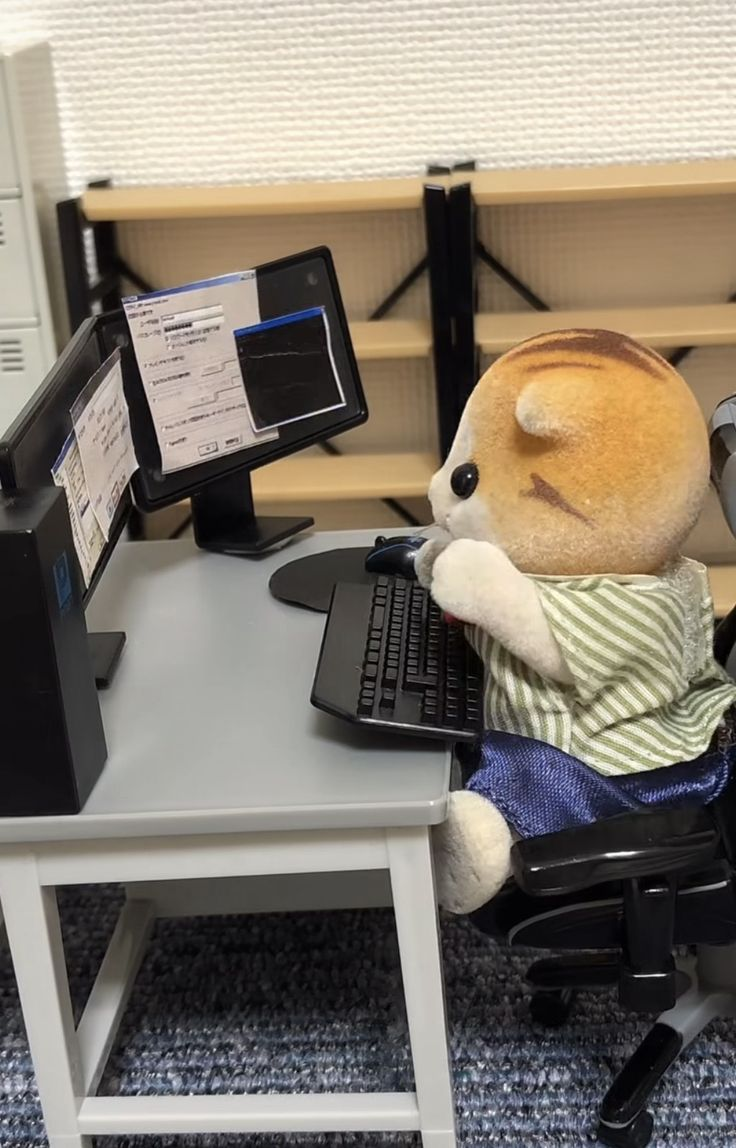


**Ejercicio (Pyton)**. Suponga que la vida util de los focos de cierta marca, se modela mediante una distribución expoencial de parametro $\theta$ (desconocido). Probamos 5 focos y encontramos que tienen una vida útil de $2,3,1,3$ y $5$ años, respectivamente. ¿Cuál es el MLE para $\theta$?

Sabemos que

$$ f(x*i;\theta) = \theta \exp(-\theta x*{i}) , x\ge 0, \theta>0 $$

$$ L(x,\theta) = \prod*{i=1}^{n} f(x_i;\theta) = \prod*{i=1}^{n} \theta \exp(-\theta x\_{i}) = \theta^{n}e^{-\theta \sum x_i}$$

$$ \ln L(x,\theta) = n\ln(\theta)-\theta\sum\_{i}x_i$$

$$\frac{d \ln L(x,\theta)}{d\theta} = \frac{n}{\theta}-\sum_{i}x_i = 0$$

$$ \hat{\theta} = \frac{n}{\sum\_{i}x_i} = 1 / \bar{X} $$


In [4]:
# Datos: 
datos = np.array([2,3,1,3,5])
n=len(datos)

suma = np.sum(datos)
media = np.mean(datos)
media

theta = n / suma #(1/media)

print("La media es", media)
print("El estimador de máxima verosimilitud para θ es", theta)


La media es 2.8
El estimador de máxima verosimilitud para θ es 0.35714285714285715


**Ejercicio.** Calcular el estimador con Sympy.


In [5]:
datos = np.array([2,3,1,3,5])
n=len(datos)

theta = sympy.symbols('theta', positive=True)

LogL = n * sympy.log(theta) - theta * np.sum(datos)

dLogL = sympy.diff(LogL,theta)

estimador = sympy.solve(dLogL,theta)[0]

estimador_decimal = estimador.evalf()

print(estimador)
print(f"El MLE para theta es: {estimador_decimal}")


5/14
El MLE para theta es: 0.357142857142857
